# Experiment 01 — improving sensitivity on the sight-threatening grades

Iteration on the baseline (`RETFound_DR_finetune.ipynb`) to raise **per-grade
sensitivity**, especially for the rare, clinically dangerous grades **R2 / R3**.

## Baseline recap & its weakness
The baseline (ViT-L, 224 px, inverse-frequency weighted cross-entropy, checkpoint
selected by validation QWK) reached eye-level **QWK 0.745 / macro-AUROC 0.888** and a
strong **referable-DR** detector (AUROC 0.965, sens 0.895). But per-grade sensitivity was
uneven: **R0 0.88, R1 0.52, R2 0.77, R3 0.46** → macro-sensitivity only **0.657**. Missing
~half of proliferative (R3) eyes is the key clinical gap.

## What changed in this experiment (three coupled changes)

| # | Change | Baseline | Experiment 01 | Why |
|---|--------|----------|---------------|-----|
| 1 | **Input resolution** | 224 px | **384 px** | R1/R2 are defined by *microaneurysms* (tens of µm) — barely resolvable at 224. Higher resolution is the single biggest lever for lesion-level sensitivity. The 512 px speed-cache already supports it; pos-embed is interpolated by RETFound's `interpolate_pos_embed`. |
| 2 | **Loss** | weighted CE | **Focal loss (γ=2)** + inverse-freq class weights | Focal down-weights easy R0/R1 examples and concentrates learning on hard minority (R2/R3) cases, lifting their recall. γ=0 reduces to weighted CE. |
| 3 | **Checkpoint selection** | validation **QWK** | validation **macro-sensitivity** | Selects the epoch that best balances recall *across all grades* — directly targeting the clinical priority instead of overall agreement. |

**Config deltas:** batch 16→**8**, accum 4→**8** (effective batch stays **64**), `input_size` 224→384,
`output_dir` → `outputs/experiment01`. Everything else (RETFound recipe: layer-wise LR decay 0.65,
drop_path 0.2, weight decay 0.05, blr 5e-3, 50 epochs, warmup 10) is unchanged from baseline.

> ⚠️ **Tradeoff:** selecting on macro-sensitivity alone can favour higher recall at some cost to
> specificity. `SELECTION_METRIC` below can be set to `"balanced"` (½·sens+½·spec) or `"qwk"` instead.
> Always then pick the deployment **operating point** from the referable-DR sweep in the eval notebook —
> do not judge sensitivity at the default 0.5 threshold.

## ⚠️ Gated model access — do this once before running
Same as the baseline: accept the form at
<https://huggingface.co/YukunZhou/RETFound_mae_natureCFP> and
`huggingface-cli login --token <YOUR_HF_TOKEN>`. If HF is unreachable,
set `os.environ["HF_ENDPOINT"]="https://hf-mirror.com"` before the model-build cell.

In [1]:
# --- ensure Phases 0-3 + speed cache + RETFound repo exist (skips if already built) ---
import os, subprocess, sys
PROJECT = os.path.abspath(".")
assert os.path.isdir("pipeline"), "Run this notebook from the project root (Retfound.V2/)."
if not os.path.isdir("outputs/dr_imagefolder"):
    for s in ["build_manifest.py", "make_split.py", "materialize_imagefolder.py"]:
        print("running", s); subprocess.run([sys.executable, f"pipeline/{s}"], check=True)
if not os.path.isdir("outputs/dr_imagefolder_cache"):
    print("building resize speed-cache (one-time)...")
    subprocess.run([sys.executable, "pipeline/build_resized_cache.py", "--size", "512"], check=True)
if not os.path.isdir("RETFound_repo"):
    subprocess.run(["git","clone","--depth","1","https://github.com/rmaphoh/RETFound.git","RETFound_repo"], check=True)
    subprocess.run([sys.executable,"-m","pip","install","-q","-r","RETFound_repo/requirements.txt"], check=True)
print("ready")

ready


In [2]:
# ============================ CONFIG (Experiment 01) ============================
CONFIG = dict(
    data_path   = "outputs/dr_imagefolder_cache",   # 512px cache supports 384 training
    nb_classes  = 4,
    input_size  = 384,                               # <-- change 1: 224 -> 384
    finetune_id = "RETFound_mae_natureCFP",
    drop_path   = 0.2,
    adaptation  = "finetune",

    # change 2: focal loss
    focal_gamma = 2.0,                               # 0.0 == weighted CE

    # optimisation (RETFound recipe; batch/accum adjusted for 384px VRAM)
    batch_size    = 8,     # 384px ViT-L peaks ~6GB @ bs8 on 16GB (bs12 OOMs)
    accum_iter    = 8,     # effective batch = 8*8 = 64 (same as baseline)
    epochs        = 50,
    warmup_epochs = 10,
    blr           = 5e-3,
    layer_decay   = 0.65,
    weight_decay  = 0.05,
    min_lr        = 1e-6,
    clip_grad     = None,

    device      = "cuda",
    seed        = 42,
    num_workers = 12,
    output_dir  = "outputs/experiment01",            # separate from baseline
    task        = "dr_exp01_384_focal_msens",
)
# change 3: select the best checkpoint by validation macro-sensitivity
SELECTION_METRIC = "macro_sensitivity"   # or "balanced" (½sens+½spec) | "qwk" | "macro_auroc"
import os; os.makedirs(CONFIG["output_dir"], exist_ok=True)
CONFIG

{'data_path': 'outputs/dr_imagefolder_cache',
 'nb_classes': 4,
 'input_size': 384,
 'finetune_id': 'RETFound_mae_natureCFP',
 'drop_path': 0.2,
 'adaptation': 'finetune',
 'focal_gamma': 2.0,
 'batch_size': 8,
 'accum_iter': 8,
 'epochs': 50,
 'warmup_epochs': 10,
 'blr': 0.005,
 'layer_decay': 0.65,
 'weight_decay': 0.05,
 'min_lr': 1e-06,
 'clip_grad': None,
 'device': 'cuda',
 'seed': 42,
 'num_workers': 12,
 'output_dir': 'outputs/experiment01',
 'task': 'dr_exp01_384_focal_msens'}

In [3]:
# ============================ imports, seeds, device ============================
import os, sys, json, time, copy
import numpy as np, torch
sys.path.insert(0, "pipeline"); sys.path.insert(0, "RETFound_repo")
import dr_train as T, dr_eval as E
from dr_losses import FocalLoss                          # <-- change 2
from engine_finetune import train_one_epoch              # RETFound's train loop (imported)

args = T.make_args(CONFIG)
T.set_seed(CONFIG["seed"]); torch.backends.cudnn.benchmark = True
device = torch.device(CONFIG["device"] if torch.cuda.is_available() else "cpu")
print("device:", device, "| input_size:", CONFIG["input_size"], "| torch", torch.__version__)

/home/eth/miniforge3/envs/retfound/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda | input_size: 384 | torch 2.5.1+cu121


In [4]:
# ============================ data + class weights ============================
(ds_tr, ds_va, ds_te), (dl_tr, dl_va, dl_te) = T.build_loaders(args, shuffle_train=True)
print("images  train/val/test:", len(ds_tr), len(ds_va), len(ds_te))
assert ds_tr.class_to_idx == json.load(open("outputs/class_mapping.json"))["ordinal_class_to_index"]
class_weights, counts = T.class_weights_from_dataset(ds_tr, CONFIG["nb_classes"], device)
print("train class counts :", counts)
print("class weights      :", class_weights.cpu().numpy().round(3))

images  train/val/test: 5853 1268 1286
train class counts : [3369 1909  299  276]
class weights      : [0.152 0.269 1.718 1.861]


In [5]:
# ============================ build model + load GATED weights ============================
model = T.build_model_arch(args)                     # ViT-L @ 384 (global_pool)
msg = T.load_pretrained(model, args)                 # hf download + pos-embed interpolation 224->384
model.to(device)
print("missing keys (expect head.* + fc_norm.*):", list(msg.missing_keys))
print(f"unexpected keys: {len(msg.unexpected_keys)} (MAE decoder — discarded)")
print(f"trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6:.1f} M")

/home/eth/Desktop/isaack/Retfound.V2/pipeline/dr_train.py:108: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(ckpt_path, map_location="cpu")


Position interpolate from 14x14 to 24x24
missing keys (expect head.* + fc_norm.*): ['fc_norm.weight', 'fc_norm.bias', 'head.weight', 'head.bias']
unexpected keys: 106 (MAE decoder — discarded)
trainable params: 303.7 M


In [ ]:
# ============================ optimizer + FOCAL criterion + scaler ============================
optimizer, loss_scaler = T.build_optimizer(model, args)          # layer-wise LR decay + AdamW + AMP
criterion = FocalLoss(weight=class_weights, gamma=CONFIG["focal_gamma"])   # <-- change 2
print(f"param groups: {len(optimizer.param_groups)} | base lr: {args.lr:.2e} | eff batch: {args.batch_size*args.accum_iter}")
print("criterion:", type(criterion).__name__, "gamma=" CONFIG["focal_gamma"])

param groups: 52 | base lr: 1.25e-03 | eff batch: 64
criterion: FocalLoss gamma= 2.0


/home/eth/Desktop/isaack/Retfound.V2/RETFound_repo/util/misc.py:249: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self._scaler = torch.cuda.amp.GradScaler()


In [ ]:
# ============================ training loop (select by val macro-sensitivity) ============================
from sklearn.metrics import cohen_kappa_score, roc_auc_score

def val_scores():
    y, p = E.predict(model, dl_va, device)
    pred = p.argmax(1)
    qwk = cohen_kappa_score(y, pred, weights="quadratic", labels=list(range(CONFIG["nb_classes"])))
    try:
        yoh = np.eye(CONFIG["nb_classes"])[y]; cols = [c for c in range(CONFIG["nb_classes"]) if yoh[:,c].sum()>0]
        auroc = roc_auc_score(yoh[:,cols], p[:,cols], average="macro", multi_class="ovr")
    except Exception: auroc = float("nan")
    msens, mspec = E.macro_sens_spec(y, pred)
    return float(qwk), float(auroc), msens, mspec

def selection_score(qwk, auroc, msens, mspec):
    return {"macro_sensitivity": msens, "balanced": 0.5*(msens+mspec),
            "qwk": qwk, "macro_auroc": auroc}[SELECTION_METRIC]

best_score, best_epoch, history = -1.0, -1, []
ckpt_path = os.path.join(CONFIG["output_dir"], "checkpoint-best.pth")
t0 = time.time()
for epoch in range(CONFIG["epochs"]):
    tr = train_one_epoch(model, criterion, dl_tr, optimizer, device, epoch,
                         loss_scaler, args.clip_grad, None, None, args)
    qwk, auroc, msens, mspec = val_scores()
    score = selection_score(qwk, auroc, msens, mspec)
    history.append({"epoch": epoch, "train_loss": tr["loss"], "val_qwk": qwk, "val_macro_auroc": auroc,
                    "val_macro_sensitivity": msens, "val_macro_specificity": mspec, "selection_score": score})
    tag = ""
    if score > best_score:
        best_score, best_epoch = score, epoch
        torch.save({"model": copy.deepcopy(model.state_dict()), "epoch": epoch, "config": CONFIG,
                    "selection_metric": SELECTION_METRIC, "val_qwk": qwk, "val_macro_auroc": auroc,
                    "val_macro_sensitivity": msens, "val_macro_specificity": mspec}, ckpt_path)
        tag = "  <-- best"
    print(f"epoch {epoch:02d}  loss={tr['loss']:.4f}  val_QWK={qwk:.4f}  AUROC={auroc:.4f}  "
          f"mSens={msens:.4f}  mSpec={mspec:.4f}{tag}")
json.dump(history, open(os.path.join(CONFIG["output_dir"], "history.json"), "w"), indent=2)
print(f"\nDone in {(time.time()-t0)/60:.1f} min. Best epoch {best_epoch}  {SELECTION_METRIC}={best_score:.4f}")

/home/eth/Desktop/isaack/Retfound.V2/RETFound_repo/engine_finetune.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch: [0]  [  0/731]  eta: 0:12:59  lr: 0.000000  loss: 0.4633 (0.4633)  time: 1.0666  data: 0.3730  max mem: 5783
Epoch: [0]  [ 20/731]  eta: 0:04:00  lr: 0.000003  loss: 0.1642 (0.2303)  time: 0.3015  data: 0.0001  max mem: 9258
Epoch: [0]  [ 40/731]  eta: 0:03:41  lr: 0.000007  loss: 0.1641 (0.2619)  time: 0.3029  data: 0.0001  max mem: 9258
Epoch: [0]  [ 60/731]  eta: 0:03:32  lr: 0.000010  loss: 0.2720 (0.2664)  time: 0.3063  data: 0.0001  max mem: 9258
Epoch: [0]  [ 80/731]  eta: 0:03:25  lr: 0.000014  loss: 0.2827 (0.2600)  time: 0.3123  data: 0.0001  max mem: 9258
Epoch: [0]  [100/731]  eta: 0:03:17  lr: 0.000016  loss: 0.2945 (0.2621)  time: 0.3068  data: 0.0001  max mem: 9258
Epoch: [0]  [120/731]  eta: 0:03:11  lr: 0.000021  loss: 0.2837 (0.2683)  time: 0.3104  data: 0.0001  max mem: 9258
Epoch: [0]  [140/731]  eta: 0:03:04  lr: 0.000023  loss: 0.1505 (0.2617)  time: 0.3093  data: 0.0001  max mem: 9258
Epoch: [0]  [160/731]  eta: 0:02:58  lr: 0.000027  loss: 0.1618 (0.2635)

/home/eth/Desktop/isaack/Retfound.V2/pipeline/dr_eval.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp):


epoch 00  loss=0.2727  val_QWK=0.1287  AUROC=0.6973  mSens=0.3865  mSpec=0.7467  <-- best


/home/eth/Desktop/isaack/Retfound.V2/RETFound_repo/engine_finetune.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

epoch 48  loss=0.1468  val_QWK=0.7407  AUROC=0.8918  mSens=0.7109  mSpec=0.9004


/home/eth/Desktop/isaack/Retfound.V2/RETFound_repo/engine_finetune.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch: [49]  [  0/731]  eta: 0:08:50  lr: 0.000003  loss: 0.4347 (0.4347)  time: 0.7252  data: 0.4214  max mem: 9258
Epoch: [49]  [ 20/731]  eta: 0:04:00  lr: 0.000003  loss: 0.1049 (0.1639)  time: 0.3190  data: 0.0001  max mem: 9258
Epoch: [49]  [ 40/731]  eta: 0:03:48  lr: 0.000003  loss: 0.0953 (0.1546)  time: 0.3226  data: 0.0001  max mem: 9258
Epoch: [49]  [ 60/731]  eta: 0:03:39  lr: 0.000003  loss: 0.0985 (0.1573)  time: 0.3181  data: 0.0001  max mem: 9258
Epoch: [49]  [ 80/731]  eta: 0:03:31  lr: 0.000003  loss: 0.0914 (0.1468)  time: 0.3218  data: 0.0001  max mem: 9258
Epoch: [49]  [100/731]  eta: 0:03:24  lr: 0.000002  loss: 0.0974 (0.1454)  time: 0.3187  data: 0.0001  max mem: 9258
Epoch: [49]  [120/731]  eta: 0:03:17  lr: 0.000002  loss: 0.0817 (0.1393)  time: 0.3218  data: 0.0001  max mem: 9258
Epoch: [49]  [140/731]  eta: 0:03:10  lr: 0.000002  loss: 0.0908 (0.1348)  time: 0.3181  data: 0.0001  max mem: 9258
Epoch: [49]  [160/731]  eta: 0:03:04  lr: 0.000002  loss: 0.0888

/home/eth/Desktop/isaack/Retfound.V2/pipeline/dr_eval.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp):


epoch 49  loss=0.1442  val_QWK=0.7401  AUROC=0.8920  mSens=0.7105  mSpec=0.9001

Done in 207.6 min. Best epoch 36  macro_sensitivity=0.7215


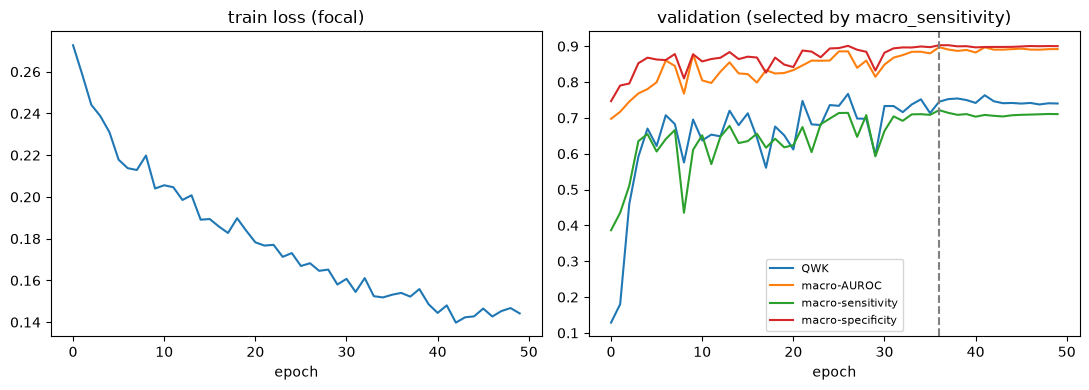

In [8]:
# ---- training curves ----
import matplotlib.pyplot as plt
h = history; ep = [x["epoch"] for x in h]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(ep, [x["train_loss"] for x in h]); ax[0].set_title("train loss (focal)"); ax[0].set_xlabel("epoch")
for k, lab in [("val_qwk","QWK"),("val_macro_auroc","macro-AUROC"),
               ("val_macro_sensitivity","macro-sensitivity"),("val_macro_specificity","macro-specificity")]:
    ax[1].plot(ep, [x[k] for x in h], label=lab)
ax[1].axvline(best_epoch, ls="--", c="grey"); ax[1].legend(fontsize=8)
ax[1].set_title(f"validation (selected by {SELECTION_METRIC})"); ax[1].set_xlabel("epoch")
fig.tight_layout(); plt.show()

## Quick test-set check
Full, publication-quality evaluation lives in **`evaluation/experiment01_evaluation.ipynb`**
(run it after training). The cell below prints a quick eye-level summary so you can compare
against the baseline immediately.

In [ ]:
# ============================ quick eval on TEST (best checkpoint) ============================
best = torch.load(ckpt_path, map_location="cpu")
model.load_state_dict(best["model"]); model.to(device)
print(f"Best epoch {best['epoch']} | val macro-sens {best['val_macro_sensitivity']:.4f} | val QWK {best['val_qwk']:.4f}")

test_paths = [p for p, _ in ds_te.samples]
y_true, y_prob = E.predict(model, dl_te, device)
rep = E.full_report(test_paths, y_true, y_prob, os.path.join(CONFIG["output_dir"], "eval_test"))
r = rep["eye_level"]; b = r["binary_referable"]
print(f"\nEYE-LEVEL (n={r['n']}): QWK={r['qwk']:.4f}  macroAUROC={r['macro_auroc_ovr']:.4f}  "
      f"macro_sens={r['macro_sensitivity']:.4f}  macro_spec={r['macro_specificity']:.4f}")
print("per-class sens/spec:", {['R0','R1','R2','R3'][k]: (round(v['sensitivity'],3), round(v['specificity'],3))
                               for k, v in r['per_class'].items()})
print(f"referable-DR: AUROC={b['auroc']:.4f} sens={b['sensitivity']:.3f} spec={b['specificity']:.3f} @0.5")

/tmp/ipykernel_217493/1115968262.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best = torch.load(ckpt_path, map_location="cpu")


Best epoch 36 | val macro-sens 0.7215 | val QWK 0.7451


/home/eth/Desktop/isaack/Retfound.V2/pipeline/dr_eval.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp):



EYE-LEVEL (n=584): QWK=0.7368  macroAUROC=0.8917  macro_sens=0.6789  macro_spec=0.9008
per-class sens/spec: {'R0': (0.871, 0.801), 'R1': (0.619, 0.864), 'R2': (0.771, 0.956), 'R3': (0.455, 0.982)}
referable-DR: AUROC=0.9662 sens=0.825 spec=0.941 @0.5


: 

## Compare to baseline (eye level)
| metric | baseline (224, wCE, QWK-sel) | experiment 01 (384, focal, mSens-sel) |
|---|---|---|
| QWK | 0.745 | _(fill after run)_ |
| macro-AUROC | 0.888 | _(fill)_ |
| macro-sensitivity | 0.657 | _(fill)_ |
| R2 / R3 sensitivity | 0.77 / 0.46 | _(fill)_ |
| referable sens / spec @0.5 | 0.895 / 0.937 | _(fill)_ |

Same fixed seed (42) and identical patient-level split, so differences are attributable to the
three changes. Remember the small-N caveat for R2/R3 — confirm gains hold under k-fold CV before
treating them as real.